# IVP, then if fails, optimise residual

In [7]:
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import clear_output
from process.main import SingleRun
from pathlib import Path
import process
from scipy.stats import qmc

In [ ]:
%matplotlib inline

# Require debug iteration csvs
process.solver.DEBUG_DATAFRAME_OUTPUT = True

# Study set up
N = 10
ne = np.linspace(7.5e19, 1.1e20, num=N)
te = np.linspace(8.5, 13.0, num=N)
te_grid, ne_grid = np.meshgrid(te, ne)


def evaluate(
    ne,
    te,
    p_hcd_primary_extra_heat_mw,
    molflow_plasma_fuelling_required,
    triang,
    w_frac,
):
    input_file = "data/lt_sol_high_W_IN.DAT"
    single_run = SingleRun(input_file)
    # Change to evaluation run
    process.data_structure.numerics.ioptimz = -2
    # Loading single run overwrites variables: set again
    process.data_structure.physics_variables.nd_plasma_electrons_vol_avg = ne
    process.data_structure.physics_variables.temp_plasma_electron_vol_avg_kev = te

    # If supplied, overwrite default values
    if (
        not np.isnan(p_hcd_primary_extra_heat_mw).all()
        and not np.isnan(molflow_plasma_fuelling_required).all()
    ):
        process.data_structure.current_drive_variables.p_hcd_primary_extra_heat_mw = (
            p_hcd_primary_extra_heat_mw
        )
        process.data_structure.physics_variables.molflow_plasma_fuelling_required = (
            molflow_plasma_fuelling_required
        )
    if not np.isnan(triang).all():
        process.data_structure.physics_variables.triang = triang
    if not np.isnan(w_frac).all():
        process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[
            13
        ] = w_frac

    try:
        # Handle failed runs
        single_run.run()
    except Exception as e:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, e
        # raise Exception(f"Error evaluating te = {te:.3e}, ne = {ne:.3e}")

    # PPB
    ppb = process.constraints.constraint_equation_2().normalised_residual
    # Fuel equilibrium
    fe = process.constraints.constraint_equation_93().normalised_residual
    return (
        ppb,
        fe,
        # beta limit
        process.constraints.constraint_equation_24().normalised_residual,
        # Greenwald limit (check)
        process.constraints.constraint_equation_5().normalised_residual,
        # L-H threshold
        process.constraints.constraint_equation_15().normalised_residual,
        # Residual
        residual(),
        # Error
        None,
    )


def solve(
    ne_init=None,
    te_init=None,
    p_hcd_primary_extra_heat_mw=None,
    molflow_plasma_fuelling_required=None,
    triang=None,
    w_frac=None,
):
    input_file = "data/lt_sol_high_W_IN.DAT"
    single_run = SingleRun(input_file)
    if p_hcd_primary_extra_heat_mw and molflow_plasma_fuelling_required:
        process.data_structure.current_drive_variables.p_hcd_primary_extra_heat_mw = (
            p_hcd_primary_extra_heat_mw
        )
        process.data_structure.physics_variables.molflow_plasma_fuelling_required = (
            molflow_plasma_fuelling_required
        )
    # Set initial parameter vector
    if ne_init and te_init:
        process.data_structure.physics_variables.nd_plasma_electrons_vol_avg = ne_init
        process.data_structure.physics_variables.temp_plasma_electron_vol_avg_kev = (
            te_init
        )

    # Set uncertainties
    if triang:
        process.data_structure.physics_variables.triang = triang
    if w_frac:
        process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[
            13
        ] = w_frac
    # Might fail
    single_run.run()
    return single_run.scan.ifail


def residual():
    # Need absolute constraint residuals
    ppb = process.constraints.constraint_equation_2().constraint_error
    fe = process.constraints.constraint_equation_93().constraint_error
    ni = process.data_structure.physics_variables.nd_plasma_ions_total_vol_avg
    ne = process.data_structure.physics_variables.nd_plasma_electrons_vol_avg
    te = process.data_structure.physics_variables.temp_plasma_electron_vol_avg_kev
    vol = process.data_structure.physics_variables.vol_plasma
    # In keV
    dte_dt = (
        (2 / 3) * (1 / 1.602e-19) * ((ppb * 1.0e6 * vol) / ((ni + ne) * vol))
    ) * 1e-3
    zimp = 0.0
    for imp in range(process.data_structure.impurity_radiation_module.N_IMPURITIES):
        if process.data_structure.impurity_radiation_module.impurity_arr_z[imp] > 2:
            zimp += (
                process.impurity_radiation.zav_of_te(
                    imp,
                    np.array(
                        [
                            process.data_structure.physics_variables.temp_plasma_electron_vol_avg_kev
                        ]
                    ),
                ).squeeze()
                * (
                    process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[
                        imp
                    ]
                )
            )
    f_alpha = process.data_structure.physics_variables.nd_plasma_alphas_vol_avg / ne
    dne_dt = (fe / vol) / (
        1
        - process.data_structure.physics_variables.f_nd_beam_electron
        - zimp
        - 2 * f_alpha
    )
    return np.sum(np.array((dte_dt * 1.0e-1, dne_dt * 1.0e-20)) ** 2)


def plot(
    ppb, fuel_eq, beta_lim, gw_lim, lh_lim, residual, ivp_iter_df=None, res_opt_df=None
):
    # Two plots: one to show constraints, the other to show residuals
    fig, ax = plt.subplots()
    fig.set_size_inches(9, 6)

    # ax.set_title("Minimised residuals of large tokamak with no equilibrium")
    ax.set_title("POPCON of large tokamak")

    # Plot ODE solution contours and constraints
    ax.set_xlabel("$T_e$")
    ax.set_ylabel("$n_e$")
    contours = []
    cs = ax.contour(te_grid, (ne_grid * 1e-19), ppb, levels=[0.0], colors="C0")
    # ax.clabel(cs, cs.levels, fontsize=10)
    contours.append(cs)
    contours.append(
        ax.contour(
            te_grid,
            (ne_grid * 1e-19),
            fuel_eq,
            levels=[0.0],
            colors="C1",
        )
    )
    # Stability constraints
    # if ax_num == 0:
    #     ALPHA = 0.15
    #     contours.append(
    #         ax.contourf(
    #             (ne_grid * 1e-19),
    #             te_grid,
    #             beta_lim,
    #             levels=[0.0, np.inf],
    #             colors="C2",
    #             alpha=ALPHA,
    #         )
    #     )
    #     contours.append(
    #         ax.contourf(
    #             (ne_grid * 1e-19),
    #             te_grid,
    #             gw_lim,
    #             levels=[0.0, np.inf],
    #             colors="C3",
    #             alpha=ALPHA,
    #         )
    #     )
    #     contours.append(
    #         ax.contourf(
    #             (ne_grid * 1e-19),
    #             te_grid,
    #             lh_lim,
    #             levels=[0.0, np.inf],
    #             colors="C4",
    #             alpha=ALPHA,
    #         )
    #     )

    names = []
    labels = []
    for contour in contours:
        name, label = contour.legend_elements()
        names.append(name[0])
        labels.append(label[0])
        # contour.collections

    # TODO Would be better not to hard-code, but tricky to combine multiple contour plots into single legend
    # labels = ["PPB", "Fuel eq", r"$\beta$ lim", "Greenwald lim", "L-H lim"]
    labels = ["PPB", "Fuel eq"]
    # labels = ["PPB = 0"]
    legend = ax.legend(names, labels, loc="upper left")

    # Residuals: plot here so behind iteration points
    if np.any(residual):
        cs = ax.contourf(te_grid, (ne_grid * 1e-19), residual)
        fig.colorbar(cs, label="SE residual")
    else:
        # Plot PPB as contour instead
        cs = ax.contourf(te_grid, (ne_grid * 1e-19), ppb)
        fig.colorbar(cs, label="Normalised PPB")

    # Plot integration iterations
    iteration_types = [ivp_iter_df, res_opt_df]
    label_names = ["IVP", "Opt"]
    # Debug
    # iteration_types = [res_opt_df]
    # label_names = ["Opt"]
    for iters_num, iters in enumerate(iteration_types):
        # If iters is empty, don't try to plot
        if iters is None:
            continue
        # Initial point
        ax.scatter(
            iters["te"].values[0],
            iters["ne"].values[0] * 1e-19,
            c=f"C{str(iters_num + 2)}",
            marker="o",
            label=f"{label_names[iters_num]} initial",
            edgecolors="white",
        )
        # Iterations
        ax.scatter(
            iters["te"].values[1:-1],
            iters["ne"].values[1:-1] * 1e-19,
            c=f"C{str(iters_num + 2)}",
            marker=".",
            label=f"{label_names[iters_num]} iterations",
        )
        # Highlight final point
        ax.scatter(
            iters["te"].values[-1],
            iters["ne"].values[-1] * 1e-19,
            c=f"C{str(iters_num + 2)}",
            marker="X",
            label=f"{label_names[iters_num]} final",
            edgecolors="white",
            zorder=100,
        )
        ax.add_artist(legend)

        ax.legend(loc="lower right")

    return ax


def evaluate_all(
    p_hcd_primary_extra_heat_mw=None,
    molflow_plasma_fuelling_required=None,
    triang=None,
    w_frac=None,
):
    eval_n_alpha_vec = np.vectorize(pyfunc=evaluate)
    ppb, fuel_eq, beta_lim, gw_lim, lh_lim, residual, e = eval_n_alpha_vec(
        ne_grid,
        te_grid,
        np.full_like(ne_grid, fill_value=p_hcd_primary_extra_heat_mw),
        np.full_like(ne_grid, fill_value=molflow_plasma_fuelling_required),
        np.full_like(ne_grid, fill_value=triang),
        np.full_like(ne_grid, fill_value=w_frac),
    )
    return ppb, fuel_eq, beta_lim, gw_lim, lh_lim, residual, e


def eval_solve_plot(
    ne_init=None,
    te_init=None,
    p_hcd_primary_extra_heat_mw=None,
    molflow_plasma_fuelling_required=None,
    triang=None,
    w_frac=None,
):
    EVALUATIONS_PATH = "data/evaluations.csv"
    print("Evaluating")
    # Evaluate all points
    ppb, fuel_eq, beta_lim, gw_lim, lh_lim, residual, e = evaluate_all(
        p_hcd_primary_extra_heat_mw=p_hcd_primary_extra_heat_mw,
        molflow_plasma_fuelling_required=molflow_plasma_fuelling_required,
        triang=triang,
        w_frac=w_frac,
    )
    clear_output()
    evals_df = make_df(ppb, fuel_eq, beta_lim, gw_lim, lh_lim, e)
    evals_df.to_csv(EVALUATIONS_PATH)

    # Integrate/opt
    print("Running IVP/opt solver")
    ivp_iter_df = None
    res_opt_df = None
    try:
        ifail = solve(
            ne_init=ne_init,
            te_init=te_init,
            p_hcd_primary_extra_heat_mw=p_hcd_primary_extra_heat_mw,
            molflow_plasma_fuelling_required=molflow_plasma_fuelling_required,
            triang=triang,
            w_frac=w_frac,
        )
        clear_output()
        if ifail == 1:
            print("IVP successful")
            ivp_iter_df = pd.read_csv("ivp_iterations.csv")
        elif ifail == 2:
            ivp_iter_df = pd.read_csv("ivp_evaluations.csv")
            res_opt_df = pd.read_csv("res_opt_evaluations.csv")
    except Exception as err:
        clear_output()
        print(f"IVP/opt failed: {err}")
        # Always produced even if solve_ivp fails
        ivp_iter_df = pd.read_csv("ivp_evaluations.csv")

    # Plot both
    ax = plot(
        ppb=ppb,
        fuel_eq=fuel_eq,
        beta_lim=beta_lim,
        gw_lim=gw_lim,
        lh_lim=lh_lim,
        residual=residual,
        ivp_iter_df=ivp_iter_df,
        res_opt_df=res_opt_df,
    )
    return evals_df, None, ivp_iter_df, ax


def make_df(ppb, fuel_eq, beta_lim, gw_lim, lh_lim, e):
    return pd.DataFrame(
        {
            "ne": ne_grid.flatten(),
            "te": te_grid.flatten(),
            "ppb": ppb.flatten(),
            "fuel_eq": fuel_eq.flatten(),
            "beta_lim": beta_lim.flatten(),
            "gw_lim": gw_lim.flatten(),
            "lh_lim": lh_lim.flatten(),
            "error": e.flatten(),
        }
    )


def plot_ivp(ivp_iter_df):
    # Plot
    fig, ax = plt.subplots()
    line1 = ax.plot(ivp_iter_df["t"], ivp_iter_df["te"], label="$T_e$")
    ax.set_xlabel("$t$ $(s)$")
    ax.set_ylabel("$T_e$ $(keV)$")
    ax.ticklabel_format(axis="y", useOffset=False)
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
    ax2 = ax.twinx()
    line2 = ax2.plot(ivp_iter_df["t"], ivp_iter_df["ne"], color="C1", label="$n_e$")
    ax2.set_ylabel("$n_e$ $(m^{-3})$")
    ax2.ticklabel_format(axis="y", useOffset=False)
    lns = line1 + line2
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, loc=0)
    ax.set_title("Integration of $dT_e/dt$ and $dn_e/dt$")


IVP successful


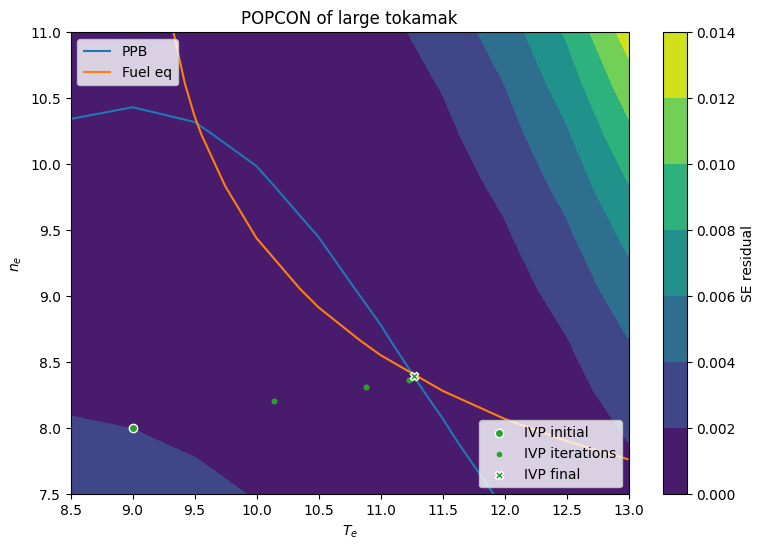

In [9]:
%matplotlib inline
# Low W
df, iter_df, ivp_iter_df, ax = eval_solve_plot(
    ne_init=8.0e19, te_init=9.0, w_frac=5.0e-6, triang=0.5
)

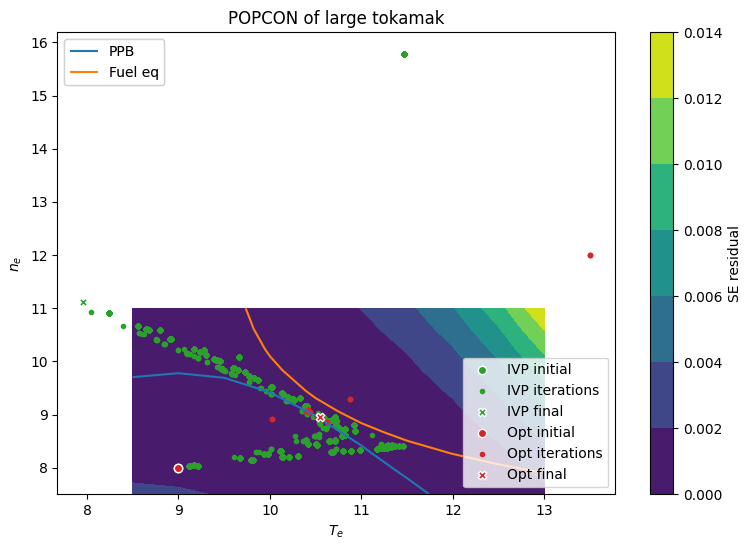

In [10]:
%matplotlib inline
# Low W
df, iter_df, ivp_iter_df, ax = eval_solve_plot(
    ne_init=8.0e19, te_init=9.0, w_frac=3.0e-5, triang=0.5
)

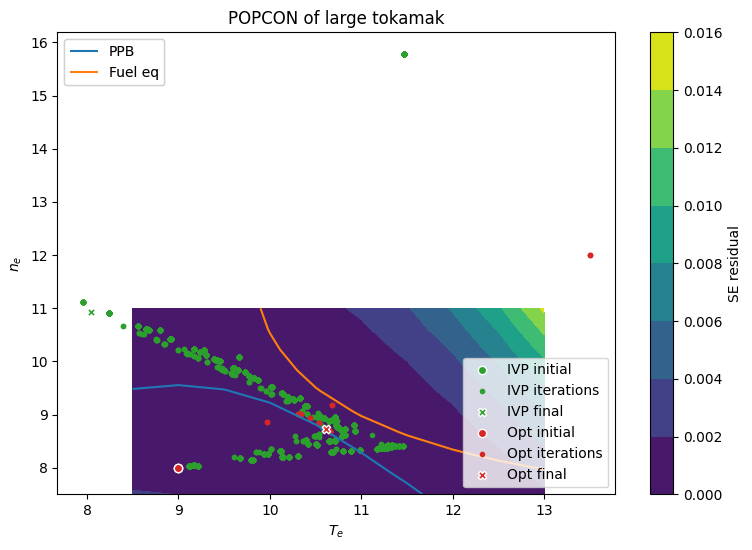

In [11]:
%matplotlib inline
# Low W
df, iter_df, ivp_iter_df, ax = eval_solve_plot(
    ne_init=8.0e19, te_init=9.0, w_frac=4.0e-5, triang=0.5
)